In [1]:
import spiceypy as spy
import pandas as pd
from Utils import *
import rebound as rb
import plotly.graph_objects as go
from scipy.optimize import newton
%load_ext autoreload 
%autoreload 2

In [3]:
path = '../datos/kernels/'
spy.furnsh([path + 'naif0012.tls', path + 'pck00010.tpc', path + 'earth_fixed.tf', path + 'earth_720101_230601.bpc', path + 'earth_latest_high_prec.bpc'])

In [5]:
fireballs = pd.read_csv('../datos/cneos_fireball_data_original.csv', comment='#')
fireballs = fireballs[["Peak Brightness Date/Time (UT)", "Latitude (deg.)", "Longitude (deg.)", "Altitude (km)", "vx", "vy", "vz"]].dropna().reset_index()

In [5]:
fireballs

,index,Peak Brightness Date/Time (UT),Latitude (deg.),Longitude (deg.),Altitude (km),vx,vy,vz
0,0,2023-08-05 19:54:50,19.9N,131.7W,44.0,3.3,20.4,-6.8
1,1,2023-07-26 03:41:54,18.9N,103.4W,36.1,-9.5,12.2,1.9
2,2,2023-07-07 16:15:31,14.5N,126.6W,38.3,2.6,4.1,-25.2
3,4,2023-06-21 19:39:13,12.4N,62.8E,40.4,7.3,-2.0,-16.4
4,5,2023-05-20 11:22:23,17.8S,141.9E,29.0,25.4,6.9,9.3
...,...,...,...,...,...,...,...,...
288,689,2004-04-22 04:21:49,44.3S,83.3E,29.6,8.5,-12.1,-6.8
289,690,2004-04-06 03:24:49,12.0S,162.8E,35.0,10.5,-23.2,-2.9
290,701,2003-11-10 13:54:06,64.5S,136.2E,23.0,14.8,-8.7,10.4
291,706,2003-09-27 12:59:02,21.0N,86.6E,26.0,-1.0,-5.4,-17.3


In [6]:
fireballs['lat'] = fireballs["Latitude (deg.)"].apply(change_coord)
fireballs['lon'] = fireballs["Longitude (deg.)"].apply(change_coord)

In [7]:
date = fireballs["Peak Brightness Date/Time (UT)"][0]
lat = fireballs["lat"][0]
lon = fireballs["lon"][0]
alt = fireballs["Altitude (km)"][0]
vx = fireballs['vx'][0]
vy = fireballs['vy'][0]
vz = fireballs['vz'][0]

r_eclip = Geo2Eclip(lon, lat, alt, date=date, frame='ITRF93') #en km
v_eclip = get_velocity_ecliptic(vx, vy, vz, lon, lat, alt, date=date)

In [8]:
r_eclip, v_eclip

(array([-3089.63618517,  5626.92213566,   -64.43090334]),
 array([ 18.0720346 , -11.43974912,  -2.49646275]))

Time TDB:  2023-08-05 19:55:59.183
Time TDB JD:  2460162.3305461016
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Position ECLIPJ200:  [ 6.80946040e-01 -7.45761161e-01  2.50411598e-04]
Velocity ECLIPJ200:  [ 0.02277991  0.00500702 -0.00144313]


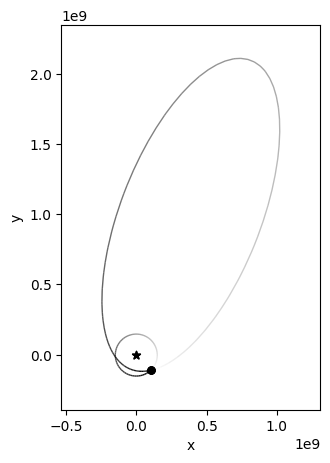

In [9]:
rb.horizons.SSL_CONTEXT = 'unverified'

AU = 149597870 #km
day = 86400

sim = rb.Simulation()
sim.units = 'km', 's', 'kg'
sim.integrator = "IAS15"
sim.dt = -86400

time = Time(date, format="iso")
print("Time TDB: ", time.tdb)
print("Time TDB JD: ", time.tdb.jd)

sim.add("Sun", hash="sun", date=f"JD{time.tdb.jd}")
sim.add("399", hash="earth", date=f"JD{time.tdb.jd}")

r_earth = np.array(sim.particles['earth'].xyz)
v_earth = np.array(sim.particles['earth'].vxyz)

r_asteroid = r_eclip + r_earth 
v_asteroid = v_eclip + v_earth #así si es 

print("Position ECLIPJ200: ", r_asteroid/AU)
print("Velocity ECLIPJ200: ", (v_asteroid/AU)*day)

asteroid = sim.add(x=r_asteroid[0], y=r_asteroid[1], z=r_asteroid[2], 
                vx=v_asteroid[0], vy=v_asteroid[1], vz=v_asteroid[2], hash="Asteroid")

fig = rb.OrbitPlot(sim)

In [10]:
hora = 3600
dia = 86400

t_end = 365*dia
print("tiempo de integracion: ", t_end)

N = 100
times = np.linspace(0, t_end, N)

state_v = np.zeros((N, 6))
earth = np.zeros((N, 3))
for i,time in enumerate(times):
    sim.integrate(-time)
    sim.move_to_hel()
    state_v[i] = sim.particles["Asteroid"].xyz + sim.particles["Asteroid"].vxyz 
    earth[i] = sim.particles["earth"].xyz

tiempo de integracion:  31536000


In [11]:
sun = sim.particles["sun"].xyz
x = state_v[:,0]
y = state_v[:,1]
# Gráfico base
fig = go.Figure(
    data=[
        # Órbita completa
        go.Scatter(x=x, y=y, mode="lines", line=dict(width=2, color="blue")),
        
        # Punto que se va a mover (inicialmente en x[0], y[0])
        go.Scatter(x=[x[0]], y=[y[0]], mode="markers", marker=dict(color="red", size=10)),

        # Tierra (estática)
        go.Scatter(x=[earth[0][0]], y=[earth[0][1]], mode="markers", marker=dict(color="blue", size=10)),

        # Sol (estático)
        go.Scatter(x=[sun[0]], y=[sun[1]], mode="markers", marker=dict(color="yellow", size=10))
    ]
)

# Botón de reproducción
fig.update_layout(
    width=700, height=550,
    title_text=f"Background integration {np.round(t_end/day)} days, impact date = {date}", title_x=0.5,
    updatemenus=[dict(
        type="buttons",
        buttons=[
            dict(
                label="Play",
                method="animate",
                args=[None, {
                    "frame": {"duration": 50, "redraw": False},
                    "fromcurrent": True,
                    "transition": {"duration": 0}
                }]
            )
        ]
    )]
)

# Animación: solo se actualiza la traza del punto rojo (índice 1)
frames = [go.Frame(
    data=[
        go.Scatter(x=[x[k]], y=[y[k]], mode="markers", marker=dict(color="red", size=10))
    ],
    traces=[1]  # Asegura que sea el índice correcto del punto animado
) for k in range(len(x))]

fig.update(frames=frames)
fig.show()

## Backward integration four orbital periods

In [12]:
rb.horizons.SSL_CONTEXT = 'unverified'
integration_times = []
nan_values = []
for i in range(len(fireballs)):
    print(f"--------- Integrating bolid {i} ------------")

    date = fireballs["Peak Brightness Date/Time (UT)"][i]
    lat = fireballs["lat"][i]
    lon = fireballs["lon"][i]
    alt = fireballs["Altitude (km)"][i]
    vx = fireballs['vx'][i]
    vy = fireballs['vy'][i]
    vz = fireballs['vz'][i]

    r_eclip = Geo2Eclip(lon, lat, alt, date=date, frame='ITRF93') #en km
    v_eclip = get_velocity_ecliptic(vx, vy, vz, lon, lat, alt, date=date)

    
    sim = rb.Simulation()
    sim.units = 'km', 's', 'kg'
    sim.integrator = "IAS15"
    sim.dt = -86400

    time = Time(date, format="iso")

    for body in ["Sun", "199", "299", "399", "499", "599", "699", "799", "899"]:
        sim.add(body, hash=f"{body}", date=f"JD{time.tdb.jd}")

    r_earth = np.array(sim.particles["399"].xyz)
    v_earth = np.array(sim.particles["399"].vxyz)

    r_asteroid = r_eclip + r_earth 
    v_asteroid = v_eclip + v_earth #así si es 

    asteroid = sim.add(x=r_asteroid[0], y=r_asteroid[1], z=r_asteroid[2], 
                    vx=v_asteroid[0], vy=v_asteroid[1], vz=v_asteroid[2], hash="Asteroid")
    asteroid = sim.particles["Asteroid"]
    orbit = asteroid.orbit()

    a = orbit.a
    mu = sim.particles["Sun"].m*sim.G
    periodo_orb = 2*np.pi*np.sqrt(a**3/mu)

    t_end = 4*periodo_orb 

    print(f"-------------- time = ({t_end}) --------------")
    
    if np.isnan(t_end):
        nan_values.append(i)
    else:
        integration_times.append({'indice': i, 'integration_time': t_end})

--------- Integrating bolid 0 ------------
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '199'... 
Found: Mercury (199) 
Searching NASA Horizons for '299'... 
Found: Venus (299) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '499'... 
Found: Mars (499) 
Searching NASA Horizons for '599'... 
Found: Jupiter (599) 
Searching NASA Horizons for '699'... 
Found: Saturn (699) 
Searching NASA Horizons for '799'... 
Found: Uranus (799) 
Searching NASA Horizons for '899'... 
Found: Neptune (899) 
-------------- time = (2475533080.4606795) --------------
--------- Integrating bolid 1 ------------
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '199'... 
Found: Mercury (199) 
Searching NASA Horizons for '299'... 
Found: Venus (299) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '499'... 
Found: Mars (499) 
Searching NASA Horizons for '599'... 
Foun

C:\Users\aguju\AppData\Local\Temp\ipykernel_38916\2760486154.py:42: RuntimeWarning:

invalid value encountered in sqrt



Found: Sun (10) 
Searching NASA Horizons for '199'... 
Found: Mercury (199) 
Searching NASA Horizons for '299'... 
Found: Venus (299) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '499'... 
Found: Mars (499) 
Searching NASA Horizons for '599'... 
Found: Jupiter (599) 
Searching NASA Horizons for '699'... 
Found: Saturn (699) 
Searching NASA Horizons for '799'... 
Found: Uranus (799) 
Searching NASA Horizons for '899'... 
Found: Neptune (899) 
-------------- time = (nan) --------------
--------- Integrating bolid 21 ------------
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '199'... 
Found: Mercury (199) 
Searching NASA Horizons for '299'... 
Found: Venus (299) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '499'... 
Found: Mars (499) 
Searching NASA Horizons for '599'... 
Found: Jupiter (599) 
Searching NASA Horizons for '699'... 
Found: Saturn (699) 
Searching NASA Hor

RuntimeError: An error occured while accessing NASA HORIZONS. If this is a SSL certificate issue, you can try disabling the certificate verification by setting rebound.horizons.SSL_CONTEXT = 'unverified'.

In [9]:
integration_times

[{'indice': 0, 'integration_time': 2475533080.4606795},
 {'indice': 1, 'integration_time': 175802418.38179025},
 {'indice': 2, 'integration_time': 207472703.0005629},
 {'indice': 3, 'integration_time': 109389270.97236589},
 {'indice': 4, 'integration_time': 662624587.1550574},
 {'indice': 5, 'integration_time': 1610222542.42337},
 {'indice': 6, 'integration_time': 688221512.6128806},
 {'indice': 7, 'integration_time': 455402129.4497518},
 {'indice': 8, 'integration_time': 84755090.19181462},
 {'indice': 9, 'integration_time': 331976499.01356417},
 {'indice': 10, 'integration_time': 562810466.2521433},
 {'indice': 11, 'integration_time': 1224381049.4086673},
 {'indice': 12, 'integration_time': 73232680672.4767},
 {'indice': 13, 'integration_time': 816146269.9864191},
 {'indice': 14, 'integration_time': 171101309.23579615},
 {'indice': 15, 'integration_time': 397593698.84957737},
 {'indice': 16, 'integration_time': 681260992.5353541},
 {'indice': 17, 'integration_time': 88669785.21724984

In [ ]:
print(f"indices NaN values: {nan_values}")

indices NaN values: [19, 20, 23, 37, 49, 57, 58, 81, 86, 98, 114, 129, 136, 145, 152, 171, 183, 186, 189, 196, 204, 205, 210, 218, 246, 256, 261, 265, 279, 280, 283]


In [11]:
len(nan_values)

31

In [23]:
orbit_elements = np.zeros((len(integration_times), 6))

for i, time  in enumerate(integration_times):
    indice = time['indice']
    int_time = time['integration_time']

    print(f"--------- Integrating bolid {indice} ------------")
    date = fireballs["Peak Brightness Date/Time (UT)"][indice]
    lat = fireballs["lat"][indice]
    lon = fireballs["lon"][indice]
    alt = fireballs["Altitude (km)"][indice]
    vx = fireballs['vx'][indice]
    vy = fireballs['vy'][indice]
    vz = fireballs['vz'][indice]

    r_eclip = Geo2Eclip(lon, lat, alt, date=date, frame='ITRF93') #en km
    v_eclip = get_velocity_ecliptic(vx, vy, vz, lon, lat, alt, date=date)

    
    sim = rb.Simulation()
    sim.units = 'km', 's', 'kg'
    sim.integrator = "IAS15"
    sim.dt = -86400

    time = Time(date, format="iso")

    for body in ["Sun", "199", "299", "399", "499", "599", "699", "799", "899"]:
        sim.add(body, hash=f"{body}", date=f"JD{time.tdb.jd}")

    r_earth = np.array(sim.particles["399"].xyz)
    v_earth = np.array(sim.particles["399"].vxyz)

    r_asteroid = r_eclip + r_earth 
    v_asteroid = v_eclip + v_earth #así si es 

    asteroid = sim.add(x=r_asteroid[0], y=r_asteroid[1], z=r_asteroid[2], 
                    vx=v_asteroid[0], vy=v_asteroid[1], vz=v_asteroid[2], hash="Asteroid")

    sim.integrate(-int_time)
    sim.move_to_hel()

    asteroid = sim.particles["Asteroid"]
    orbit = asteroid.orbit()

    orbit_elements[i] = [orbit.a, orbit.e, orbit.inc, orbit.Omega, orbit.omega, orbit.M]


--------- Integrating bolid 0 ------------
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '199'... 
Found: Mercury (199) 
Searching NASA Horizons for '299'... 
Found: Venus (299) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '499'... 
Found: Mars (499) 
Searching NASA Horizons for '599'... 
Found: Jupiter (599) 
Searching NASA Horizons for '699'... 
Found: Saturn (699) 
Searching NASA Horizons for '799'... 
Found: Uranus (799) 
Searching NASA Horizons for '899'... 
Found: Neptune (899) 
--------- Integrating bolid 1 ------------
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '199'... 
Found: Mercury (199) 
Searching NASA Horizons for '299'... 
Found: Venus (299) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '499'... 
Found: Mars (499) 
Searching NASA Horizons for '599'... 
Found: Jupiter (599) 
Searching NASA Horizons for '699'... 
Fo

### Save orbital elements 

In [27]:
fireballs_int = fireballs.drop(nan_values)

In [33]:
np.mod(orbit_elements[0][-1], 360)

6.022836564875549

In [28]:
fireballs_int['a (km)'] = orbit_elements[:,0]
fireballs_int['e'] = orbit_elements[:,1]
fireballs_int['i (rad)'] = orbit_elements[:,2]
fireballs_int['Omega (rad)'] = orbit_elements[:,3]
fireballs_int['omega (rad)'] = orbit_elements[:,4]
fireballs_int['M (rad)'] = orbit_elements[:,5]

orbital_elements_int = fireballs_int
orbital_elements_int.to_csv("datos/orbital_elements_integration.csv", index=False)

### Revisar Nans

In [14]:
date = fireballs["Peak Brightness Date/Time (UT)"][204]
lat = fireballs["lat"][204]
lon = fireballs["lon"][204]
alt = fireballs["Altitude (km)"][204]
vx = fireballs['vx'][204]
vy = fireballs['vy'][204]
vz = fireballs['vz'][204]

r_eclip = Geo2Eclip(lon, lat, alt, date=date, frame='ITRF93') #en km
v_eclip = get_velocity_ecliptic(vx, vy, vz, lon, lat, alt, date=date)

r_eclip, v_eclip

(array([ 3537.81333934,  5027.50752031, -1833.39195042]),
 array([ -7.61499282, -11.79061169,   7.9565717 ]))

In [15]:
rb.horizons.SSL_CONTEXT = 'unverified'
sim = rb.Simulation()
sim.units = 'km', 's', 'kg'
sim.integrator = "IAS15"
sim.dt = -86400

time = Time(date, format="iso")

for body in ["Sun", "199", "299", "399", "499", "599", "699", "799", "899"]:
    sim.add(body, hash=f"{body}", date=f"JD{time.tdb.jd}")

r_earth = np.array(sim.particles["399"].xyz)
v_earth = np.array(sim.particles["399"].vxyz)

r_asteroid = r_eclip + r_earth 
v_asteroid = v_eclip + v_earth #así si es 

asteroid = sim.add(x=r_asteroid[0], y=r_asteroid[1], z=r_asteroid[2], 
                vx=v_asteroid[0], vy=v_asteroid[1], vz=v_asteroid[2], hash="Asteroid")

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '199'... 
Found: Mercury (199) 
Searching NASA Horizons for '299'... 
Found: Venus (299) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '499'... 
Found: Mars (499) 
Searching NASA Horizons for '599'... 
Found: Jupiter (599) 
Searching NASA Horizons for '699'... 
Found: Saturn (699) 
Searching NASA Horizons for '799'... 
Found: Uranus (799) 
Searching NASA Horizons for '899'... 
Found: Neptune (899) 


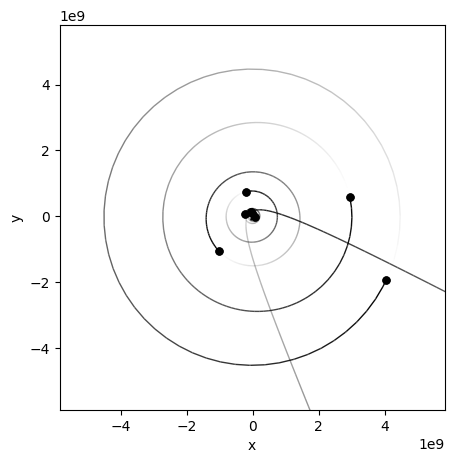

In [16]:
fig = rb.OrbitPlot(sim)

In [ ]:
asteroid = sim.particles["Asteroid"]
orbit = asteroid.orbit()

a = orbit.a
mu = sim.particles["Sun"].m*sim.G
periodo_orb = 2*np.pi*np.sqrt(a**3/mu)

t_end = 4*periodo_orb 

print(f"-------------- time = ({t_end}) --------------")

if np.isnan(t_end):
    nan_values.append(i)
else:
    integration_times.append({'indice': i, 'integration_time': t_end})

## Influence Sphere Background Integration 

In [ ]:
times = []

def SoiCross(time):

    sim.integrate(-time)
    r = np.linalg.norm(np.array(sim.particles[2].xyz) - np.array(sim.particles[1].xyz))

    return r - Rsoi

for i in range(len(fireballs)):
    print(f"--------- Integrating bolid {i} ------------")

    date = fireballs["Peak Brightness Date/Time (UT)"][i]
    lat = fireballs["lat"][i]
    lon = fireballs["lon"][i]
    alt = fireballs["Altitude (km)"][i]
    vx = fireballs['vx'][i]
    vy = fireballs['vy'][i]
    vz = fireballs['vz'][i]

    r_eclip = Geo2Eclip(lon, lat, alt, date=date, frame='ITRF93') #en km
    v_eclip = get_velocity_ecliptic(vx, vy, vz, lon, lat, alt, date=date)

    
    sim = rb.Simulation()
    sim.units = 'km', 's', 'kg'
    sim.integrator = "IAS15"
    sim.dt = -3600

    time = Time(date, format="iso")

    for i in ["Sun", "199", "299", "399", "499", "599", "699", "799", "899"]:
        sim.add(i, hash=f"{i}", date=f"JD{time.tdb.jd}")

    r_earth = np.array(sim.particles["399"].xyz)
    v_earth = np.array(sim.particles["399"].vxyz)

    r_asteroid = r_eclip + r_earth 
    v_asteroid = v_eclip + v_earth #así si es 

    asteroid = sim.add(x=r_asteroid[0], y=r_asteroid[1], z=r_asteroid[2], 
                    vx=v_asteroid[0], vy=v_asteroid[1], vz=v_asteroid[2], hash="Asteroid")

    a = 1.496e8
    Rsoi = a * (sim.particles["399"].m/sim.particles["Sun"].m)**(2/5)

    t_soi = newton(SoiCross, 3600)

    times.append(t_soi)

--------- Integrating bolid 0 ------------
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '199'... 
Found: Mercury (199) 
Searching NASA Horizons for '299'... 
Found: Venus (299) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '499'... 
Found: Mars (499) 
Searching NASA Horizons for '599'... 
Found: Jupiter (599) 
Searching NASA Horizons for '699'... 
Found: Saturn (699) 
Searching NASA Horizons for '799'... 
Found: Uranus (799) 
Searching NASA Horizons for '899'... 
Found: Neptune (899) 


In [ ]:
print(f"Rango de horas cruce esfera de influencia: {np.min(times)/hora} - {np.max(times)/hora}")

Rango de horas cruce esfera de influencia: 5.69920221823576 - 115.72036993852151


In [ ]:
positions = []


for i in range(len(fireballs)):
    print(f"--------- Integrating bolid {i} ------------")
    date = fireballs["Peak Brightness Date/Time (UT)"][i]
    lat = fireballs["lat"][i]
    lon = fireballs["lon"][i]
    alt = fireballs["Altitude (km)"][i]
    vx = fireballs['vx'][i]
    vy = fireballs['vy'][i]
    vz = fireballs['vz'][i]

    r_eclip = Geo2Eclip(lon, lat, alt, date=date, frame='ITRF93') #en km
    v_eclip = get_velocity_ecliptic(vx, vy, vz, lon, lat, alt, date=date)

    
    sim = rb.Simulation()
    sim.units = 'km', 's', 'kg'
    sim.integrator = "IAS15"
    sim.dt = -3600

    time = Time(date, format="iso")

    for i in ["Sun", "199", "299", "399", "499", "599", "699", "799", "899"]:
        sim.add(i, hash=f"{i}", date=f"JD{time.tdb.jd}")

    r_earth = np.array(sim.particles["399"].xyz)
    v_earth = np.array(sim.particles["399"].vxyz)

    r_asteroid = r_eclip + r_earth 
    v_asteroid = v_eclip + v_earth #así si es 

    asteroid = sim.add(x=r_asteroid[0], y=r_asteroid[1], z=r_asteroid[2], 
                    vx=v_asteroid[0], vy=v_asteroid[1], vz=v_asteroid[2], hash="Asteroid")

    sim.integrate(-times[i])
    positions.append(np.array(sim.particles["Asteroid"].xyz) - np.array(sim.particles["399"].xyz))

positions = np.array(positions)

--------- Integrating bolid 0 ------------
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
--------- Integrating bolid 1 ------------
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
--------- Integrating bolid 2 ------------
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
--------- Integrating bolid 3 ------------
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
--------- Integrating bolid 4 ------------
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
--------- Integrating bolid 5 ------------
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
--------- Integrating bolid 6 ------------
Searching NASA Horizo

In [ ]:
df = pd.DataFrame(columns=['x', 'y', 'z', 'r'])

df.x = positions[:,0]
df.y = positions[:,1]
df.z = positions[:,2]
r = [3e4 for j in range(len(positions[:,2]))]
df.r = r

In [ ]:
def ms(x, y, z, radius, resolution=20):
    """Return the coordinates for plotting a sphere centered at (x,y,z)"""
    u, v = np.mgrid[0:2*np.pi:resolution*2j, 0:np.pi:resolution*1j]
    X = radius * np.cos(u)*np.sin(v) + x
    Y = radius * np.sin(u)*np.sin(v) + y
    Z = radius * np.cos(v) + z
    return (X, Y, Z)

(x_earth_surface, y_earth_surface, z_earth_surface) = ms(0, 0, 0, Rsoi)
# Create a scatter plot
x_scatter = df.x  # Example scatter data
y_scatter = df.y
z_scatter = df.z

# Create 3D plot
fig = go.Figure()

# Solid sphere
fig.add_trace(go.Surface(x=x_earth_surface, y=y_earth_surface, z=z_earth_surface, colorscale='blues', opacity=0.5))

# Scatter plot
fig.add_trace(go.Scatter3d(x=x_scatter, y=y_scatter, z=z_scatter, mode='markers', marker=dict(size=3, color='red')))

fig.update_layout(scene=dict(aspectmode='data'), margin=dict(l=0, r=0, b=0, t=0))
fig.show()